In [196]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [197]:
# Import data and and divide into training and test data
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [198]:
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Shape of individual images: {X_train[0].shape}")

Training samples: 60000
Test samples: 10000
Shape of individual images: (28, 28)


In [199]:
# plt.matshow(X_train[0], cmap='gray')

In [200]:
# y_train[0]

In [201]:
# plt.matshow(X_train[1], cmap='gray')

In [202]:
# y_train[1]

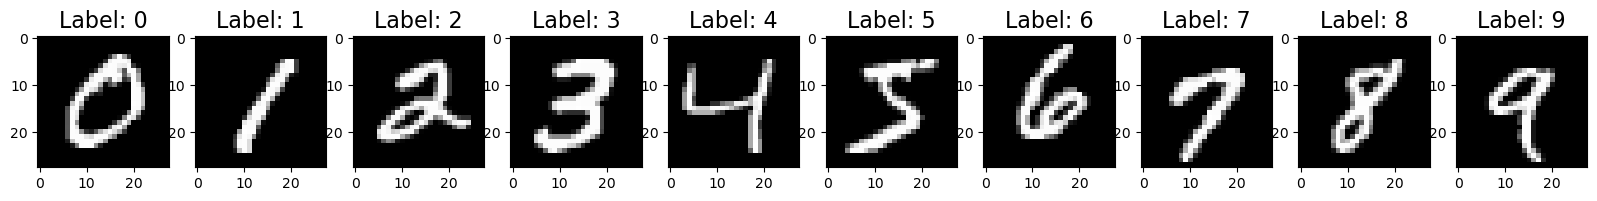

In [203]:
num_classes = 10
_, ax = plt.subplots(1, num_classes, figsize=(20, 20))
for i in range(num_classes):
    sample = X_train[y_train == i][0]
    ax[i].imshow(sample, cmap='gray')
    ax[i].set_title(f'Label: {i}', fontsize=16)

In [204]:
X_train.shape

(60000, 28, 28)

In [205]:
X_train = X_train/255
X_test = X_test/255

In [206]:
for r in X_train[2]:
    for c in r:
        if c > 0:
            print(c)

0.2627450980392157
0.9098039215686274
0.15294117647058825
0.24313725490196078
0.3176470588235294
0.47058823529411764
0.7058823529411765
0.15294117647058825
0.49411764705882355
0.6392156862745098
0.00784313725490196
0.6
0.8235294117647058
0.1568627450980392
0.8627450980392157
0.6392156862745098
0.10588235294117647
0.996078431372549
0.6352941176470588
0.8705882352941177
0.6392156862745098
0.7176470588235294
0.996078431372549
0.49019607843137253
0.1803921568627451
0.9607843137254902
0.6392156862745098
0.7764705882352941
0.996078431372549
0.2196078431372549
0.47058823529411764
0.996078431372549
0.6392156862745098
0.09019607843137255
0.9058823529411765
0.996078431372549
0.11372549019607843
0.6235294117647059
0.996078431372549
0.47058823529411764
0.6392156862745098
0.996078431372549
0.8470588235294118
0.06274509803921569
0.6235294117647059
0.996078431372549
0.2627450980392157
0.054901960784313725
0.33725490196078434
0.6980392156862745
0.9725490196078431
0.996078431372549
0.3568627450980392
0

In [207]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [208]:

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('X_train_flattened:', X_train_flattened.shape)
print('X_test_flattened:', X_test_flattened.shape)

X_train: (60000, 28, 28)
X_test: (10000, 28, 28)
X_train_flattened: (60000, 784)
X_test_flattened: (10000, 784)


# Lesson 8

## Create an initial Neural Network using Keras
We will initially use a simple network that only has an input olayer and an output layer. The input layer will have 784 neurons (28*28 pixels in each image) and the output layer will have 10 neurons as we want to predict a digit (0-9)

In [209]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(10, input_shape=(784,), activation='softmax')
    ]
)

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.fit(X_train_flattened, y_train, epochs=10)


/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8210 - loss: 0.7068
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9117 - loss: 0.3112
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9199 - loss: 0.2899
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9255 - loss: 0.2671
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9275 - loss: 0.2653
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9274 - loss: 0.2573
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9286 - loss: 0.2595
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9298 - loss: 0.2476
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9303 - loss: 0.2556
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9305 - loss: 0.2486


# Lab 8
### 1. Prediction Generation:
How can you generate predictions from a trained neural network model using a test dataset? What function or method would you use?

In [210]:
y_predicted = model.predict(X_test_flattened)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step


### 2. Accessing Prediction Details:
How would you access the prediction details for the second image in the test dataset? Which index would you use to retrieve this information from the predictions array?

In [211]:
y_predicted[1]

array([1.1711989e-04, 1.1525727e-06, 9.9336869e-01, 3.8369642e-05,
       2.3140343e-15, 3.5124812e-03, 2.9361709e-03, 5.0130221e-19,
       2.6074280e-05, 9.0930183e-16], dtype=float32)

### 3. Finding the Predicted Class:
How can you determine the predicted class from the output of a neural network? What function would you use to find the index of the highest probability?

In [212]:
int(np.argmax(y_predicted[1]))

2

### 4. Visualizing Test Data:
Which function would you use to visualize a specific test image, and what parameters might you need to provide to display it in grayscale?

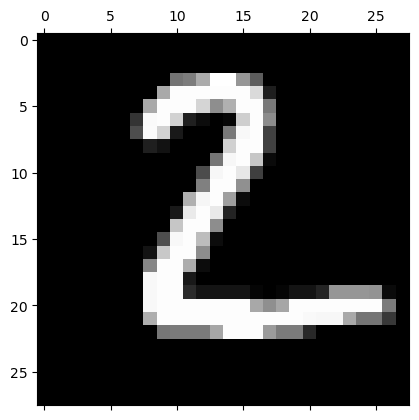

In [213]:
plt.matshow(X_test[1], cmap='gray')

### 5. Comparing with Actual Labels:
How would you retrieve the actual label for the second image in the test dataset? Which index should you use to access this information?

In [214]:
int(y_test[1])

2

### 6. Converting Predictions to Class Labels:
How can you convert a list of prediction probabilities into class labels for each test image? What Python technique or method would help you iterate over the predictions and extract the labels?

In [215]:
y_predicted_labels = [int(np.argmax(y_pred)) for y_pred in y_predicted]

### 7. Examining Initial Predictions:
How would you access the first five predicted class labels from your converted predictions? Which part of the list would you slice to get this subset?

In [216]:
y_predicted_labels[:5]

[7, 2, 1, 0, 4]

Check against the first 10 labels

In [217]:
print(y_predicted_labels[:10])
print('[' + ', '.join([str(c) for c in y_test[:10]]) + ']')

[7, 2, 1, 0, 4, 1, 4, 9, 6, 9]
[7, 2, 1, 0, 4, 1, 4, 9, 5, 9]


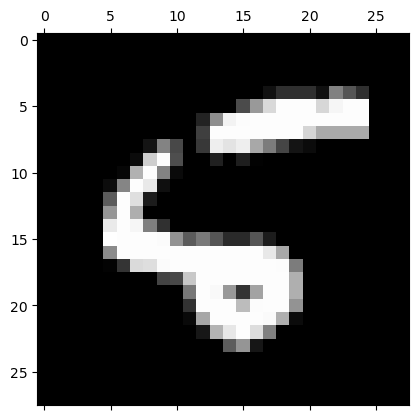

In [218]:
plt.matshow(X_test[8], cmap='gray')

In [219]:
cm = tf.math.confusion_matrix(y_test, y_predicted_labels)

In [220]:
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 954,    0,    2,    2,    0,   10,    8,    2,    1,    1],
       [   0, 1107,    6,    2,    0,    1,    3,    2,   14,    0],
       [   3,    8,  944,   12,    6,    5,   12,    8,   30,    4],
       [   3,    0,   22,  910,    1,   34,    2,   10,   22,    6],
       [   1,    1,    6,    2,  902,    0,   11,    4,   11,   44],
       [   7,    1,    5,   25,    7,  800,   11,    4,   25,    7],
       [   9,    3,   10,    1,    7,   17,  907,    1,    3,    0],
       [   1,    6,   27,    3,    5,    1,    0,  947,    3,   35],
       [   5,    6,    8,   20,    9,   30,    7,   10,  872,    7],
       [   9,    7,    1,   11,   22,    8,    0,   18,    7,  926]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

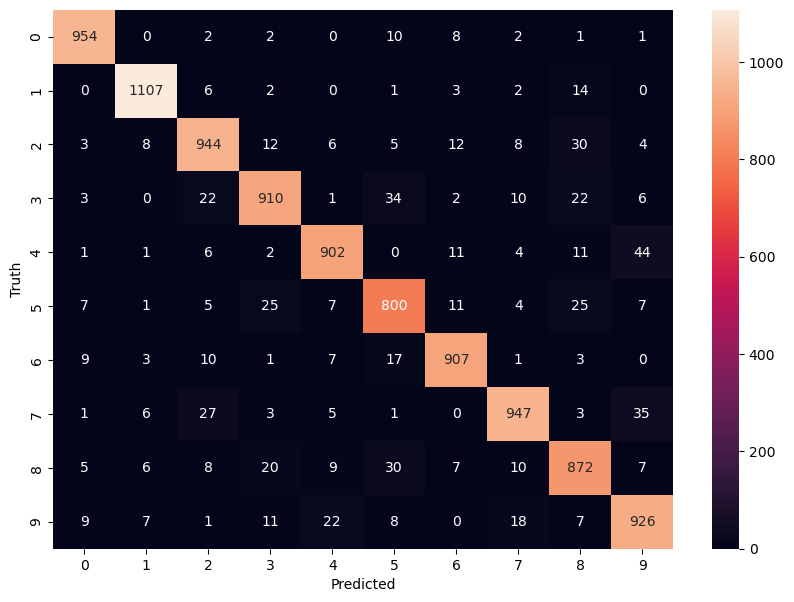

In [221]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [222]:
errors = (y_predicted_labels - y_test != 0)
num_error = sum(errors)
print(f'{num_error} / {len(y_predicted_labels)} = {num_error/len(y_predicted_labels)*100}%')
y_errors_indexes = np.where(np.array(y_predicted_labels) != np.array(y_test))[0]

731 / 10000 = 7.31%


### Check a few random predictions

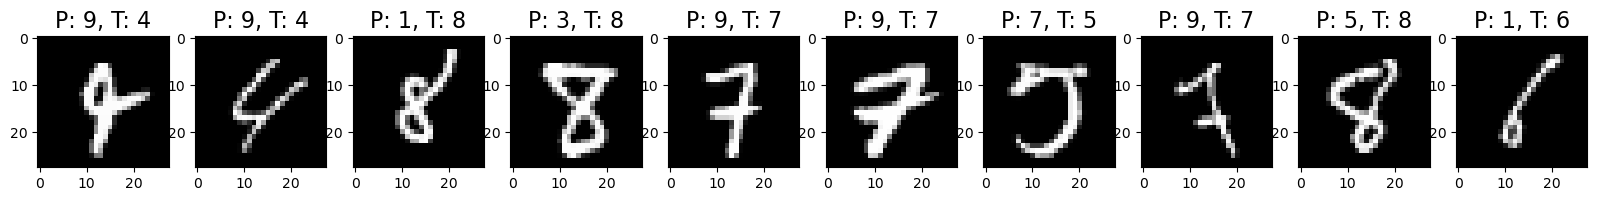

In [223]:
import random

idx_to_check = [y_errors_indexes[random.randint(0, len(y_errors_indexes)-1)] for _ in range(10)]

num_classes = 10

_, ax = plt.subplots(1, num_classes, figsize = (20,20))
for i, idx in enumerate(idx_to_check):
    sample = X_test[idx]
    predicted_value = y_predicted_labels[idx]
    true_value = y_test[idx]
    ax[i].imshow(sample, cmap='gray')
    ax[i].set_title(f'P: {predicted_value}, T: {true_value}', fontsize=16)


Add a hidden layer to our model and see if it improves the accuracy

In [224]:
model2 = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(200, input_shape=(784,), activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ]
)

model2.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model2.fit(X_train_flattened, y_train, epochs=25)

/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8855 - loss: 0.3923
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9689 - loss: 0.1055
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9805 - loss: 0.0667
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9846 - loss: 0.0488
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9897 - loss: 0.0334
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9913 - loss: 0.0285
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9944 - loss: 0.0189
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9949 - loss: 0.0168
Epoch 9/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9964 - loss: 0.0128
Epoch 10/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9976 - loss: 0.0095
Epoch 11/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9972 - loss: 0.0096
Epoch 12/25
1875/1875 ━━━━━━━━

In [225]:
y_predicted2 = model2.predict(X_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [230]:
y_predicted_labels2 = [int(np.argmax(y_pred)) for y_pred in y_predicted2]

In [231]:
cm2 = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels2)

Text(95.72222222222221, 0.5, 'Truth')

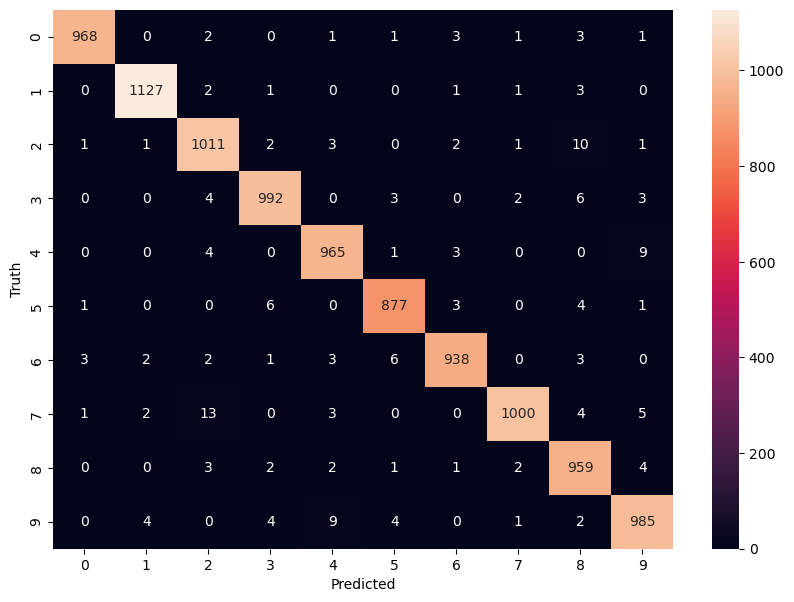

In [232]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm2, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [233]:
errors2 = (y_predicted_labels2 - y_test)
y_errors_indexes2 = [i for i, error in enumerate(errors2) if error]
len(y_errors_indexes2)

178